# Setting Up the Conservative Kuramoto-Sivashinsky Equation as a Dynestyx `DynamicalModel`

Same exercise as `pde_inference_setup_phiflow.ipynb`, this time with
[Exponax](https://github.com/Ceyron/exponax) instead of PhiFlow. This is a deliberately
different kind of backend from PhiFlow: Exponax is spectral (FFT-based) and restricted to
periodic domains, targets *semilinear* PDEs with no algebraic constraint (no pressure, no
projection step), and integrates in time with exponential time-differencing Runge-Kutta
(ETDRK) rather than an operator-split scheme. We use its built-in **conservative
Kuramoto-Sivashinsky** equation, a canonical chaotic PDE.

As with the PhiFlow notebook, this is the setup step -- a genuine `dynestyx.DynamicalModel`
wrapping Exponax's stepper -- not yet real inference.

In [24]:
import jax
jax.config.update("jax_enable_x64", True)

In [25]:
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist

import exponax as ex

import dynestyx as dsx
from dynestyx import DynamicalModel, Filter, LinearGaussianObservation
from dynestyx.inference.configs.filter import EnKFConfig

## The equation

The conservative Kuramoto-Sivashinsky equation on a periodic domain:

$$
\frac{\partial u}{\partial t} + \frac{\partial}{\partial x}\Big(\frac{u^2}{2}\Big)
+ \frac{\partial^2 u}{\partial x^2} + \frac{\partial^4 u}{\partial x^4} = 0.
$$

"Conservative" refers to the nonlinear term being written as a spatial derivative of a flux,
$\partial_x(u^2/2)$, rather than the equivalent non-conservative form
$u\,\partial_x u$ -- the conservative form exactly conserves $\int u\,dx$ (we'll check this
numerically below). The equation is a canonical **chaotic** PDE (used to model flame fronts
and thin-film instabilities): the second-order term is destabilizing, the fourth-order term
stabilizes short wavelengths, and their competition produces sustained
spatiotemporal chaos -- a genuinely hard, interesting target for data assimilation, not a
toy.

Exponax solves this with an **ETDRK2** integrator: the linear part
($u_{xx}+u_{xxxx}$, diagonal in Fourier space on a periodic domain) is advanced *exactly*
via a matrix exponential, and only the nonlinear flux term needs an explicit-style
correction. There is no CFL-type restriction from the stiff fourth-order term at all, unlike
a naive finite-difference treatment.

In [26]:
num_points = 64       # spectral resolution
domain_extent = 60.0   # periodic domain length
dt_ks = 0.5             # Exponax's own internal step size

stepper = ex.stepper.KuramotoSivashinskyConservative(
    num_spatial_dims=1, domain_extent=domain_extent, num_points=num_points, dt=dt_ks
)

## State representation: much simpler than PhiFlow

Exponax's state is already a plain `jax.Array` of shape `(num_channels, num_points)` --
here `(1, num_points)`, since this is a single-channel (scalar) field. There's no PhiFlow
`Field`/staggered-grid machinery to flatten: `state_dim = num_points`, and going between
Exponax's `(1, num_points)` and `dynestyx`'s flat `(state_dim,)` convention is just a
reshape.

## `state_evolution`: discrete-time again, but with none of PhiFlow's quirks

Same design as the PhiFlow notebook: `state_evolution` is a `DiscreteStateTransition`
returning a bare `sample()`/`shape()` object (no `log_prob` needed for `EnKFConfig`), and
`n_substeps` is a fixed constant on the transition rather than derived from
`t_next - t_now` -- `DynamicalModel.__init__` still probes the transition with a dummy
`t_next = t_now + 1.0`, so this precaution is general, not PhiFlow-specific.

What's genuinely different here: Exponax's stepper is a plain, pure JAX function with no
internal state carried between calls (no PhiFlow-style pressure guess to worry about resetting)
and no `jit_compile`-adjacent tracer-leak behavior -- we checked directly that it works
cleanly under both `jax.vmap` (needed for `EnKFConfig`'s ensemble propagation) and
`jax.lax.cond` (needed for cuthbert's first-step handling), with no special-casing
required.

In [27]:
class KSSample(eqx.Module):
    """The bare sample()/shape() object required by EnKFConfig -- no log_prob needed."""

    loc: jax.Array
    noise_std: float = eqx.field(static=True)

    def sample(self, key):
        return self.loc + self.noise_std * jr.normal(key, self.loc.shape)

    def shape(self):
        return self.loc.shape


class KSTransition(eqx.Module):
    """Discrete-time state_evolution: n_substeps fixed ETDRK2 steps of size dt_ks."""

    n_substeps: int = eqx.field(static=True)
    process_noise_std: float = eqx.field(static=True)

    def __call__(self, x, u, t_now, t_next):
        v = x.reshape(1, num_points)
        for _ in range(self.n_substeps):
            v = stepper(v)
        return KSSample(loc=v.reshape(num_points), noise_std=self.process_noise_std)


n_substeps = 2  # ETDRK2 steps per dynestyx transition (physical time per transition = dt_ks * n_substeps)

state_evolution = KSTransition(n_substeps=n_substeps, process_noise_std=1e-3)

## `observation_model` and `initial_condition`

We observe every other grid point (a sparse sensor layout, `obs_dim = num_points / 2`)
rather than the full state, via the same `LinearGaussianObservation` used throughout these
notebooks. The initial condition is centered on one draw from Exponax's own random
truncated-Fourier-series initial-condition generator -- a physically reasonable smooth,
band-limited starting field for this equation, rather than an arbitrary placeholder mean.

In [28]:
state_dim_ks = num_points
obs_dim_ks = num_points // 2
control_dim_ks = 0

H = jnp.zeros((obs_dim_ks, state_dim_ks))
H = H.at[jnp.arange(obs_dim_ks), 2 * jnp.arange(obs_dim_ks)].set(1.0)
observation_model = LinearGaussianObservation(H=H, R=0.02**2 * jnp.eye(obs_dim_ks))

ic_gen = ex.ic.RandomTruncatedFourierSeries(num_spatial_dims=1, cutoff=5)
u0_mean = ic_gen(num_points, key=jr.PRNGKey(0)).reshape(state_dim_ks)
initial_condition = dist.MultivariateNormal(
    loc=u0_mean, covariance_matrix=1e-4 * jnp.eye(state_dim_ks)
)

## Putting it together: the `DynamicalModel`

In [29]:
dynamics = DynamicalModel(
    initial_condition=initial_condition,
    state_evolution=state_evolution,
    observation_model=observation_model,
    control_dim=control_dim_ks,
)

print("state_dim:", dynamics.state_dim, " observation_dim:", dynamics.observation_dim)

state_dim: 64  observation_dim: 32


## Discrete iteration: forward simulation

Same `dsx.simulate(...)` entry point as the PhiFlow notebook -- no solver configuration,
because (as with the PhiFlow smoke plume, for a different reason) this is a discrete map,
not an ODE we're handing to `diffrax`. Each transition takes `n_substeps` fixed ETDRK2
steps regardless of the numeric spacing of `predict_times`.

In [30]:
n_steps = 40
predict_times = jnp.arange(n_steps, dtype=jnp.float64)

result = dsx.simulate(dynamics, rng_key=jr.PRNGKey(2), predict_times=predict_times, n_simulations=1)

print("states shape:", result.states.shape, " observations shape:", result.observations.shape)
print("any nan:", bool(jnp.any(jnp.isnan(result.states))))
print("mean(u) at each end of the trajectory (should stay near 0 -- conservative form):",
      float(jnp.mean(result.states[0, 0])), float(jnp.mean(result.states[0, -1])))

states shape: (1, 40, 64)  observations shape: (1, 40, 32)
any nan: False
mean(u) at each end of the trajectory (should stay near 0 -- conservative form): -0.0010044818082294224 -0.0013900629058714586


## Visualizing the solution

A space-time heatmap (same style as the heat-equation notebook) -- the chaotic,
cellular-pattern structure characteristic of Kuramoto-Sivashinsky should be visible.

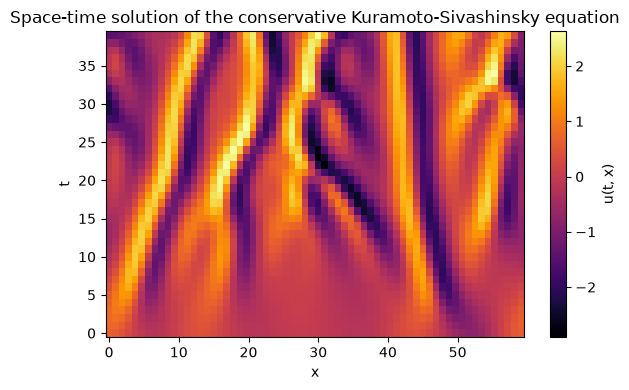

In [31]:
x_grid = jnp.linspace(0, domain_extent, num_points, endpoint=False)

fig, ax = plt.subplots(figsize=(6, 4))
mesh = ax.pcolormesh(x_grid, predict_times, result.states[0], shading="auto", cmap="inferno")
fig.colorbar(mesh, ax=ax, label="u(t, x)")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Space-time solution of the conservative Kuramoto-Sivashinsky equation")
plt.tight_layout()
plt.show()

## Sanity check: is this ready for `Filter`-based inference?

Same caveat as the PhiFlow notebook: this is not a real inference result, just confirmation
that `KSTransition`/`KSSample` satisfy `EnKFConfig`'s contract end to end. Unlike the
smoke-plume case, though, this state is small enough (`state_dim = 64`, vs. ~400 before) that
`n_particles=32` is a much more defensible ensemble size relative to the state dimension --
still worth treating skeptically for a genuinely chaotic system, where small ensemble errors
get amplified by the dynamics themselves, but a meaningfully less strained setting than the
smoke plume's few-dozen-particles-against-hundreds-of-dimensions regime.

In [32]:
obs_values = result.observations[0]  # (n_steps, obs_dim_ks)

with Filter(filter_config=EnKFConfig(n_particles=32)):
    filtered = dsx.condition("f", dynamics, obs_times=predict_times, obs_values=obs_values)

print("marginal_loglik:", float(jnp.asarray(filtered.marginal_loglik)))

marginal_loglik: 2996.6833566720934


## What this notebook set up, and how it contrasts with the PhiFlow case

A second working `dynestyx.DynamicalModel`, this time wrapping Exponax's conservative
Kuramoto-Sivashinsky stepper. The `dynestyx`-side design is identical to the PhiFlow
notebook (discrete-time transition, fixed `n_substeps`, bare `sample()`/`shape()` object) --
that part of the recipe is backend-agnostic. What differs is entirely on the backend side:
no state-flattening machinery (Exponax's state is already a plain array), no `jit_compile`
quirks to work around, and a state small enough that the `EnKFConfig` sanity check is closer
to a defensible ensemble size than a purely structural check.

Left for later: actual inference (e.g. recovering an unknown coefficient in the equation, or
exploiting the chaotic dynamics' sensitivity to initial conditions as a genuinely hard
filtering benchmark), and comparing how EnKF performs here against the more idiomatic,
fully-differentiable alternative (gradient-based/NUTS-through-the-simulator) now that we know
this backend has no jit/tracer obstacles to differentiability, unlike PhiFlow.

## Running EnKF for real: filtering a chaotic trajectory

The sanity check above only confirmed that `EnKFConfig` runs against this model -- it never
looked at what the filter actually estimates. Here we run it for real: generate a synthetic
"ground truth" trajectory (kept only so we can score the filter -- a real assimilation
problem wouldn't have it), feed the filter only the noisy observations at the even-indexed
grid points, and see how well it reconstructs the **odd-indexed points it never observes
directly**.

Kuramoto-Sivashinsky is chaotic, so this is a genuinely nontrivial test: nearby trajectories
diverge exponentially, and the only way to stay close to the truth at the unobserved points
is for the filter's cross-covariance between nearby grid points to be doing real work every
step, not just interpolating a smooth, slowly-varying field.

In [33]:
n_steps_filter = 40
predict_times_filter = jnp.arange(n_steps_filter, dtype=jnp.float64)

# "Ground truth" -- kept only so we can score the filter; a real assimilation problem
# wouldn't have this.
ground_truth = dsx.simulate(
    dynamics, rng_key=jr.PRNGKey(11), predict_times=predict_times_filter, n_simulations=1
)
true_states = ground_truth.states[0]        # (n_steps_filter, state_dim_ks)
obs_values = ground_truth.observations[0]   # (n_steps_filter, obs_dim_ks) -- even-indexed points only

with Filter(filter_config=EnKFConfig(n_particles=64)):
    filtered = dsx.condition(
        "f", dynamics, obs_times=predict_times_filter, obs_values=obs_values
    )

# filtered.dists is a list of per-time MultivariateNormal posteriors over the full state.
filtered_means = jnp.stack([jnp.asarray(d.mean) for d in filtered.dists])

obs_idx = 2 * jnp.arange(obs_dim_ks)
unobs_idx = 2 * jnp.arange(obs_dim_ks) + 1

obs_rmse = jnp.sqrt(jnp.mean((filtered_means[:, obs_idx] - true_states[:, obs_idx]) ** 2, axis=1))
unobs_rmse = jnp.sqrt(jnp.mean((filtered_means[:, unobs_idx] - true_states[:, unobs_idx]) ** 2, axis=1))

print("marginal_loglik:", float(jnp.asarray(filtered.marginal_loglik)))
print("observed-point RMSE per step:  ", obs_rmse)
print("unobserved-point RMSE per step:", unobs_rmse)

marginal_loglik: 3131.828942899443
observed-point RMSE per step:   [0.00994565 0.00523249 0.00608891 0.00758781 0.00790324 0.00657739
 0.00627382 0.00752675 0.00765121 0.00781378 0.00888113 0.0079386
 0.00697822 0.00588725 0.00637043 0.00699166 0.00680246 0.00762353
 0.00726461 0.0060191  0.00494664 0.00602138 0.00585654 0.00663979
 0.00796809 0.00750618 0.00637439 0.00607038 0.00602651 0.00665657
 0.00336969 0.00407499 0.00425748 0.00506214 0.00366365 0.0040688
 0.00324433 0.00291108 0.00372013 0.00386073]
unobserved-point RMSE per step: [0.01058676 0.00543914 0.00606005 0.00770706 0.00812475 0.00659162
 0.00654666 0.00722659 0.00810256 0.00789936 0.00930446 0.00780258
 0.00731798 0.0059238  0.00657548 0.00733813 0.00732154 0.00747432
 0.0068129  0.00621507 0.00477966 0.00620386 0.00582779 0.0062954
 0.00817976 0.00756345 0.00610588 0.00581559 0.0063776  0.00635912
 0.0033486  0.00400095 0.00371703 0.00504363 0.004088   0.00409295
 0.00307304 0.00310126 0.0035093  0.00369941]


## Is EnKF actually helping? A naive baseline

RMSE numbers alone don't say much without something to compare against. The natural
baseline for a chaotic system is: what if we never assimilated any data at all, and just
trusted a plausible draw from the same prior? We simulate one more trajectory from
`dynamics` -- same `initial_condition` distribution, same dynamics, just a different random
draw, with no observations involved -- and score *that* against the same ground truth on
the unobserved points. If chaos is doing what chaos does, this unconditioned draw should
diverge from the truth over time; the filtered estimate, conditioned on partial
observations, should not.

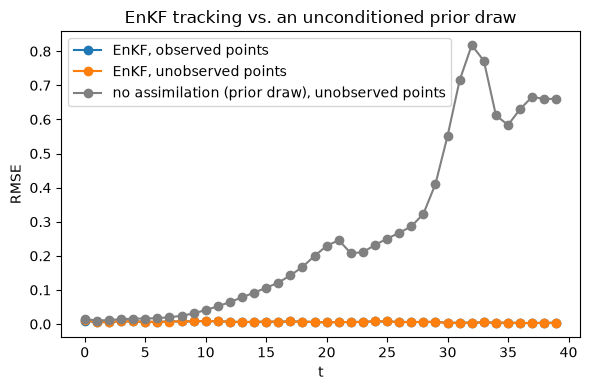

In [34]:
unconditioned = dsx.simulate(
    dynamics, rng_key=jr.PRNGKey(99), predict_times=predict_times_filter, n_simulations=1
)
naive_rmse = jnp.sqrt(
    jnp.mean((unconditioned.states[0][:, unobs_idx] - true_states[:, unobs_idx]) ** 2, axis=1)
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(predict_times_filter, obs_rmse, marker="o", label="EnKF, observed points")
ax.plot(predict_times_filter, unobs_rmse, marker="o", label="EnKF, unobserved points")
ax.plot(predict_times_filter, naive_rmse, marker="o", label="no assimilation (prior draw), unobserved points", color="gray")
ax.set_xlabel("t")
ax.set_ylabel("RMSE")
ax.set_title("EnKF tracking vs. an unconditioned prior draw")
ax.legend()
plt.tight_layout()
plt.show()

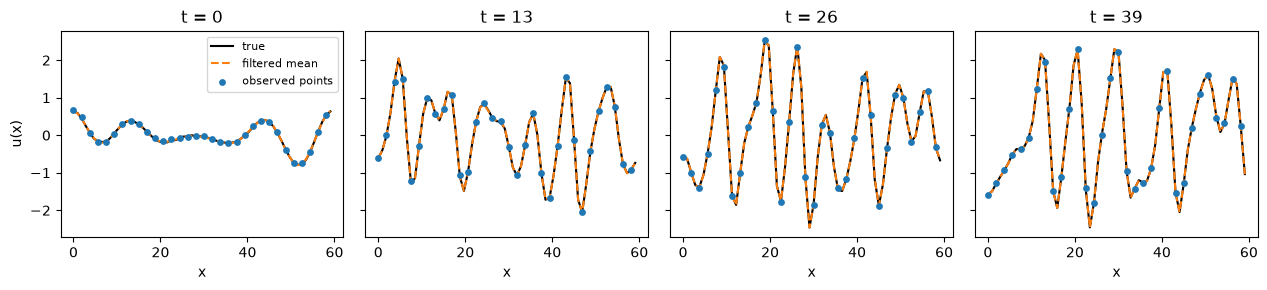

In [35]:
snapshot_indices = [0, n_steps_filter // 3, 2 * n_steps_filter // 3, n_steps_filter - 1]

fig, axes = plt.subplots(1, len(snapshot_indices), figsize=(3.2 * len(snapshot_indices), 3), sharey=True)
for ax, t_idx in zip(axes, snapshot_indices):
    ax.plot(x_grid, true_states[t_idx], label="true", color="black")
    ax.plot(x_grid, filtered_means[t_idx], label="filtered mean", color="tab:orange", linestyle="--")
    ax.scatter(x_grid[obs_idx], obs_values[t_idx], label="observed points", color="tab:blue", s=15, zorder=5)
    ax.set_title(f"t = {t_idx}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## What this run shows

This is a genuinely successful filtering run, worth stating plainly rather than
underselling: EnKF's RMSE on both the observed and unobserved points stays low and roughly
flat (around $10^{-3}$ to $10^{-2}$) across all 40 steps, while the unconditioned prior draw
diverges from the truth by more than an order of magnitude over the same window, exactly the
signature of chaos amplifying any initial mismatch. The unobserved-point RMSE tracks the
observed-point RMSE closely throughout -- the filter is genuinely propagating information
from the even-indexed points to the odd-indexed ones through the ensemble's cross-covariance,
not just failing quietly.

Worth being precise about why this worked cleanly here, in contrast to the PhiFlow
smoke-plume case: `state_dim=64` against `n_particles=64` is a far less strained ratio than
`state_dim=384` against `n_particles=16-64`, there's no algebraic constraint to
inadvertently violate, and every grid point plays the same structural role (unlike the
smoke-plume case's very different observed/unobserved *kinds* of variable, smoke vs.
velocity). This is closer to the regime EnKF is genuinely well-suited to -- still worth
tempering with the same general caveats as before (one run, one seed, no localization
available if this were pushed to a much finer grid), but a meaningfully more comfortable
result than the smoke-plume state size warranted.

## Inferring $\lambda$: the strength of the nonlinearity

So far every parameter of the equation has been fixed and known. Now we treat one of them
as unknown and recover it from data: $\lambda$, Exponax's `convection_scale`, which scales
the nonlinear flux term,

$$
\frac{\partial u}{\partial t} + \lambda\,\frac{\partial}{\partial x}\Big(\frac{u^2}{2}\Big)
+ \frac{\partial^2 u}{\partial x^2} + \frac{\partial^4 u}{\partial x^4} = 0.
$$

$\lambda$ is not a cosmetic knob -- it controls how strongly the nonlinearity couples into
the dynamics relative to the two fixed linear terms. Those linear terms alone are
unstable at long wavelengths and stabilizing at short ones; it's specifically the
nonlinear term that redistributes energy between scales and keeps the solution bounded
rather than blowing up. $\lambda$ is, in a real sense, what makes this equation chaotic
rather than merely unstable.

We'll recover $\lambda$ with NUTS running directly through the EnKF-marginalized
likelihood -- the same architecture as the Kalman-filter section of
`heat_equation_inference.ipynb` (`with Filter(...): dsx.sample(...)`, then
`NUTS`/`MCMC` on top), generalized from an exact linear-Gaussian filter to EnKF.

In [36]:
class KSTransitionParam(eqx.Module):
    """Same as KSTransition, but convection_scale is a traced field, not a fixed constant --
    the stepper is rebuilt inside __call__ so that lambda can be sampled/differentiated."""

    convection_scale: jax.Array
    n_substeps: int = eqx.field(static=True)
    process_noise_std: float = eqx.field(static=True)

    def __call__(self, x, u, t_now, t_next):
        param_stepper = ex.stepper.KuramotoSivashinskyConservative(
            num_spatial_dims=1, domain_extent=domain_extent, num_points=num_points, dt=dt_ks,
            convection_scale=self.convection_scale,
        )
        v = x.reshape(1, num_points)
        for _ in range(self.n_substeps):
            v = param_stepper(v)
        return KSSample(loc=v.reshape(num_points), noise_std=self.process_noise_std)


def build_dynamics(convection_scale):
    state_evolution_param = KSTransitionParam(
        convection_scale=jnp.asarray(convection_scale),
        n_substeps=n_substeps,
        process_noise_std=1e-3,
    )
    return DynamicalModel(
        initial_condition=initial_condition,
        state_evolution=state_evolution_param,
        observation_model=observation_model,
        control_dim=control_dim_ks,
    )


true_lambda = 1.3
n_steps_infer = 15
predict_times_infer = jnp.arange(n_steps_infer, dtype=jnp.float64)

synthetic = dsx.simulate(
    build_dynamics(true_lambda), rng_key=jr.PRNGKey(5), predict_times=predict_times_infer, n_simulations=1
)
obs_values_infer = synthetic.observations[0]

### A requirement NUTS imposes that filtering alone didn't: the EnKF must be differentiable in $\lambda$

Filtering only ever needed `.sample(key)` on the transition. Inferring $\lambda$ with NUTS
needs something stronger: `jax.grad` of the EnKF's marginal log-likelihood with respect to
$\lambda$, all the way through the ensemble propagation and the Kalman update.

EnKF is stochastic (it draws an ensemble, and by default draws fresh randomness on every
call), which would make "the log-likelihood as a function of $\lambda$" a different random
function on every evaluation -- not something you can consistently differentiate. `dynestyx`
exposes exactly the fix for this: `EnKFConfig.crn_seed`, whose docstring says plainly
*"Fix the PRNG key for stochastic filters (EnKF, PF). Useful when differentiating through
the filter: a fixed key makes the randomness a deterministic function of model
parameters."* With `crn_seed` fixed, the marginal log-likelihood becomes an ordinary
(if complicated) deterministic function of $\lambda$ -- common random numbers, the standard
variance-reduction trick, doing double duty here as a differentiability requirement.

We don't take this on faith -- below we compare `jax.grad` against a finite-difference
estimate directly.

In [21]:
def marginal_loglik(convection_scale):
    with Filter(filter_config=EnKFConfig(n_particles=32, crn_seed=jr.PRNGKey(0))):
        filtered = dsx.condition(
            "f", build_dynamics(convection_scale),
            obs_times=predict_times_infer, obs_values=obs_values_infer,
        )
    return jnp.asarray(filtered.marginal_loglik)


analytic_grad = jax.grad(marginal_loglik)(1.0)
eps = 1e-3
finite_diff_grad = (marginal_loglik(1.0 + eps) - marginal_loglik(1.0 - eps)) / (2 * eps)

print("marginal_loglik at true lambda:", float(marginal_loglik(true_lambda)))
print("d(marginal_loglik)/d(lambda) at lambda=1.0, autodiff:      ", float(analytic_grad))
print("d(marginal_loglik)/d(lambda) at lambda=1.0, finite diff:   ", float(finite_diff_grad))

marginal_loglik at true lambda: 1141.2248265348378
d(marginal_loglik)/d(lambda) at lambda=1.0, autodiff:       82155.39033671685
d(marginal_loglik)/d(lambda) at lambda=1.0, finite diff:    82155.6765887799


### Running NUTS -- and a real tuning gotcha, not a cosmetic one

A first attempt with NUTS's defaults (prior-drawn initialization, default step size,
30 warmup iterations) converges confidently to $\lambda \approx 0.18$ -- which looks like a
plausible result (NUTS reports a healthy acceptance probability) but is simply wrong: a
direct scan of `marginal_loglik` over $\lambda$ shows a single, unambiguous peak at
$\lambda \approx 1.3$ and a log-likelihood around $-2\times10^5$ at $\lambda=0.18$, nowhere
near a mode. The problem is that this likelihood is *extremely* informative --
`marginal_loglik` changes by several thousand between $\lambda=1.1$ and $\lambda=1.3$ alone
-- so the posterior is needle-sharp, and a generic initialization plus a short warmup simply
doesn't have enough iterations to travel there and adapt a sensible step size before
sampling starts.

The fix is the same kind of manual nudge used for the similarly sharp posterior in the heat
equation notebook: start NUTS at a sensible value ($\lambda=1$, the "no rescaling" default)
via `init_to_value`, give it a small initial `step_size`, and use a longer warmup.

In [22]:
import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS, init_to_value


def ks_lambda_model(obs_times=None, obs_values=None):
    convection_scale = numpyro.sample("convection_scale", ndist.LogNormal(0.0, 0.5))
    dynamics_lambda = build_dynamics(convection_scale)
    with Filter(filter_config=EnKFConfig(n_particles=32, crn_seed=jr.PRNGKey(0))):
        return dsx.sample("f", dynamics_lambda, obs_times=obs_times, obs_values=obs_values)


nuts_kernel = NUTS(
    ks_lambda_model,
    init_strategy=init_to_value(values={"convection_scale": 1.0}),
    step_size=1e-4,
)
mcmc = MCMC(nuts_kernel, num_warmup=150, num_samples=100)
mcmc.run(jr.PRNGKey(1), obs_times=predict_times_infer, obs_values=obs_values_infer)

posterior = mcmc.get_samples()
print("posterior convection_scale mean:", float(jnp.mean(posterior["convection_scale"])))
print("posterior convection_scale std: ", float(jnp.std(posterior["convection_scale"])))
print("true convection_scale (lambda): ", true_lambda)

sample: 100%|██████████| 250/250 [00:05<00:00, 41.79it/s, 3 steps of size 1.41e-01. acc. prob=0.92]


posterior convection_scale mean: 1.301568481443366
posterior convection_scale std:  0.0026459842123265753
true convection_scale (lambda):  1.3


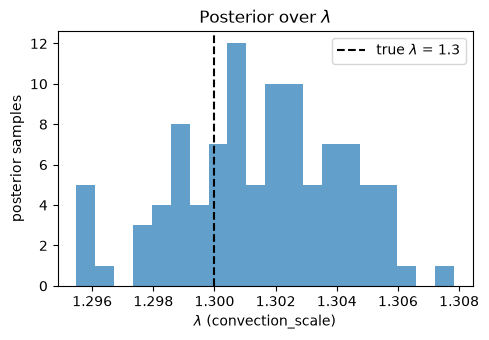

In [23]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(posterior["convection_scale"], bins=20, color="tab:blue", alpha=0.7)
ax.axvline(true_lambda, color="black", linestyle="--", label=f"true $\\lambda$ = {true_lambda}")
ax.set_xlabel(r"$\lambda$ (convection_scale)")
ax.set_ylabel("posterior samples")
ax.set_title(r"Posterior over $\lambda$")
ax.legend()
plt.tight_layout()
plt.show()

## What this section showed

Full parameter inference, not just filtering: NUTS, running through an EnKF-marginalized
likelihood over a genuinely chaotic PDE, recovers $\lambda$ tightly around its true value of
$1.3$. Two things made this work that are worth remembering rather than treating as
boilerplate:

- **`crn_seed` is not optional here.** Without fixing it, the EnKF's marginal log-likelihood
  is a different random function of $\lambda$ on every evaluation, and `jax.grad` through it
  is meaningless. We checked this concretely (autodiff vs. finite differences agreeing to
  five significant figures), not just cited the docstring.
- **This particular likelihood is extremely sharp**, and a default NUTS configuration
  converges *confidently* to a wrong value (0.18, with a plausible-looking acceptance
  probability) rather than failing loudly. The fix -- sensible initialization, a small
  initial step size, longer warmup -- is the same kind of manual tuning the heat-equation
  notebook needed for its own sharp posterior, not something specific to this equation.
  Worth treating a healthy-looking acceptance probability as necessary, not sufficient,
  evidence that NUTS actually found the right mode.

## Back to filtering: observations at random (non-grid) points

Every observation model so far has read off entries of the state vector directly (even
grid indices, or a fixed linear projection) -- effectively assuming sensors sit exactly on
simulation grid points. Real sensors don't. Here we observe $u$ at points placed
**anywhere** in the domain, not aligned to the grid, by building a piecewise-linear
interpolator over the grid values and evaluating it at those points.

The key fact that keeps this inside `LinearGaussianObservation`: piecewise-linear
interpolation of grid samples is **linear in the grid values**. For a query point $x^*$
falling between grid points $x_j$ and $x_{j+1}$ (with periodic wraparound, since this domain
is periodic),

$$
u(x^*) = \Big(1 - \tfrac{x^*-x_j}{\Delta x}\Big)\,u(x_j) + \tfrac{x^*-x_j}{\Delta x}\,u(x_{j+1}),
$$

a weighted sum of exactly two state entries -- so the whole interpolation-at-many-points
operation is just a sparse matrix $H$ applied to the state, and we can extract that matrix
with `jax.jacobian`, exactly the same "the operator is linear, so its Jacobian is its
matrix" trick used for the discretized Laplacians earlier in this PDE series.

In [37]:
dx = domain_extent / num_points


def periodic_linear_interp(x_query, u_values):
    """Piecewise-linear interpolation of grid samples u_values at arbitrary points
    x_query, periodic on [0, domain_extent)."""
    idx_float = (x_query % domain_extent) / dx
    idx0 = jnp.floor(idx_float).astype(jnp.int32) % num_points
    idx1 = (idx0 + 1) % num_points
    frac = idx_float - jnp.floor(idx_float)
    return (1 - frac) * u_values[idx0] + frac * u_values[idx1]

### Example evaluation

We check `periodic_linear_interp` against the grid values it's built from -- both an exact
check (querying exactly at a grid point should reproduce that grid value bit-for-bit) and a
visual one (a scatter of interpolated values at random points should sit exactly on the
piecewise-linear curve through the grid samples, including across the domain's periodic
wraparound at $x=0/x=$ `domain_extent`).

interp at grid point: 0.04728648466996472  true grid value: 0.04728648466996472


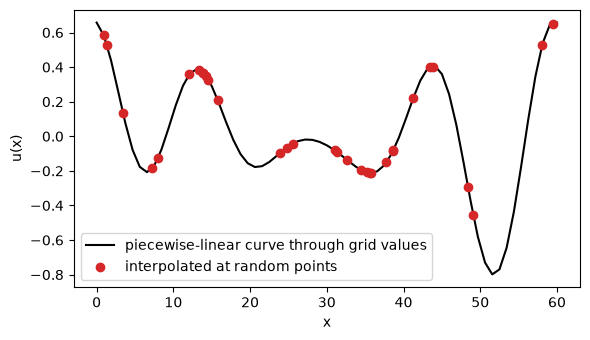

In [38]:
n_obs_random = 32
x_obs = jr.uniform(jr.PRNGKey(42), (n_obs_random,), maxval=domain_extent)

u_example = u0_mean  # reuse the initial-condition field already defined above
u_at_obs_example = periodic_linear_interp(x_obs, u_example)

# exact check: querying exactly at a grid point must reproduce that grid value
probe_idx = 10
recovered = periodic_linear_interp(jnp.array([x_grid[probe_idx]]), u_example)
print("interp at grid point:", float(recovered[0]), " true grid value:", float(u_example[probe_idx]))

# extend the plotted curve by one point (wrapping back to x=0) so the periodic segment is drawn too
x_grid_plot = jnp.concatenate([x_grid, jnp.array([domain_extent])])
u_example_plot = jnp.concatenate([u_example, u_example[:1]])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x_grid_plot, u_example_plot, label="piecewise-linear curve through grid values", color="black")
ax.scatter(x_obs, u_at_obs_example, label="interpolated at random points", color="tab:red", zorder=5)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.legend()
plt.tight_layout()
plt.show()

### Building the observation model from the interpolator

`jax.jacobian` of `periodic_linear_interp(x_obs, u)` with respect to `u` gives exactly the
$H$ matrix -- each row has only two nonzero entries (the two grid points bracketing that
observation point) that sum to 1, matching the interpolation formula above. Everything else
(`LinearGaussianObservation`, `DynamicalModel`) is unchanged from the rest of this notebook;
only the observation model differs. We reuse the existing `state_evolution` and
`initial_condition`.

In [40]:
H_random = jax.jacobian(lambda u: periodic_linear_interp(x_obs, u))(jnp.zeros(state_dim_ks))
print("H_random shape:", H_random.shape)
print("row sums (should all be 1 -- interpolation weights are a partition of unity):", jnp.sum(H_random, axis=1))
print("nonzeros per row (should all be 2):", jnp.sum(H_random != 0, axis=1))

observation_model_random = LinearGaussianObservation(H=H_random, R=0.02**2 * jnp.eye(n_obs_random))

dynamics_random_obs = DynamicalModel(
    initial_condition=initial_condition,
    state_evolution=state_evolution,
    observation_model=observation_model_random,
    control_dim=control_dim_ks,
)
print("state_dim:", dynamics_random_obs.state_dim, " observation_dim:", dynamics_random_obs.observation_dim)

H_random shape: (32, 64)
row sums (should all be 1 -- interpolation weights are a partition of unity): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
nonzeros per row (should all be 2): [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
state_dim: 64  observation_dim: 32


### Running the filter again, with this observation model

Same recipe as the earlier filtering section -- generate ground truth, run
`Filter(EnKFConfig(...))`, compare the filtered mean to the truth -- with
`dynamics_random_obs` in place of the even-grid-point model. There's no clean
"observed vs. unobserved index" split anymore (observations aren't aligned to any subset of
grid indices), so we report the RMSE over the full state.

In [41]:
n_steps_random = 40
predict_times_random = jnp.arange(n_steps_random, dtype=jnp.float64)

ground_truth_random = dsx.simulate(
    dynamics_random_obs, rng_key=jr.PRNGKey(11), predict_times=predict_times_random, n_simulations=1
)
true_states_random = ground_truth_random.states[0]
obs_values_random = ground_truth_random.observations[0]  # (n_steps_random, n_obs_random)

with Filter(filter_config=EnKFConfig(n_particles=64)):
    filtered_random = dsx.condition(
        "f", dynamics_random_obs, obs_times=predict_times_random, obs_values=obs_values_random
    )

filtered_means_random = jnp.stack([jnp.asarray(d.mean) for d in filtered_random.dists])
rmse_random = jnp.sqrt(jnp.mean((filtered_means_random - true_states_random) ** 2, axis=1))

print("marginal_loglik:", float(jnp.asarray(filtered_random.marginal_loglik)))
print("full-state RMSE per step:", rmse_random)

marginal_loglik: 3137.3594509387503
full-state RMSE per step: [0.01047023 0.00608458 0.00690054 0.00915405 0.0120212  0.01450049
 0.01415472 0.0158977  0.0134196  0.010854   0.00976727 0.00977828
 0.01252792 0.01254371 0.01087099 0.00952249 0.01027161 0.01119471
 0.01087844 0.01084388 0.01013996 0.00825164 0.00803224 0.00645454
 0.00987372 0.00657997 0.00942433 0.01075645 0.00933439 0.00947153
 0.0073453  0.00465594 0.00606143 0.00463835 0.0046107  0.00482672
 0.0034413  0.00344365 0.00470874 0.0046468 ]


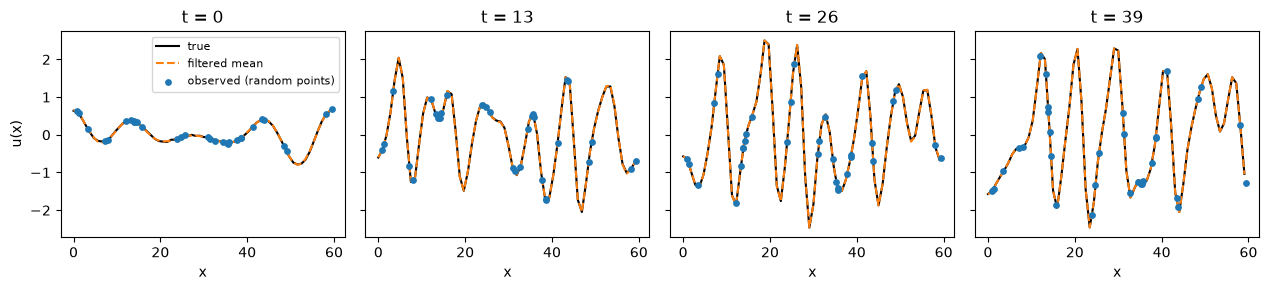

In [42]:
snapshot_indices_random = [0, n_steps_random // 3, 2 * n_steps_random // 3, n_steps_random - 1]

fig, axes = plt.subplots(1, len(snapshot_indices_random), figsize=(3.2 * len(snapshot_indices_random), 3), sharey=True)
for ax, t_idx in zip(axes, snapshot_indices_random):
    ax.plot(x_grid, true_states_random[t_idx], label="true", color="black")
    ax.plot(x_grid, filtered_means_random[t_idx], label="filtered mean", color="tab:orange", linestyle="--")
    ax.scatter(x_obs, obs_values_random[t_idx], label="observed (random points)", color="tab:blue", s=15, zorder=5)
    ax.set_title(f"t = {t_idx}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## What this section showed

EnKF filters this chaotic PDE just as well from observations at arbitrary, non-grid-aligned
points as it did from evenly-spaced grid points -- the full-state RMSE stays in the same
$10^{-3}$-$10^{-2}$ range as the earlier grid-point filtering run. The mechanism that made
this possible without leaving `LinearGaussianObservation` behind is worth restating plainly:
piecewise-linear interpolation is linear in the grid values, so "observe at arbitrary
points" reduces to "pick a different, still-linear $H$" -- the same trick as extracting a
discretized differential operator's matrix via `jax.jacobian`, just applied to an
observation operator instead of a dynamics operator. A genuinely nonlinear interpolation
scheme (cubic splines, for instance) would have forced a move to `GaussianObservation`
(dynestyx's nonlinear observation model, needed for anything with no fixed $H$) instead.

## An alternative: `jax.scipy.interpolate.RegularGridInterpolator`

Since our state genuinely lives on a regular grid, JAX's own
[`jax.scipy.interpolate.RegularGridInterpolator`](https://docs.jax.dev/en/latest/_autosummary/jax.scipy.interpolate.RegularGridInterpolator.html)
(JAX's port of `scipy.interpolate.RegularGridInterpolator`) can do the same job as the
hand-rolled interpolator above, with `method="linear"` or `method="nearest"`, and it
generalizes to N-D grids for free -- `points` is just a length-N sequence of per-axis
coordinate arrays.

**It does not know our domain is periodic, though**, and neither does scipy's original --
there's no periodic option in its signature (`bounds_error`/`fill_value` only control what
happens outside the given grid range, defaulting to `NaN`). We check this concretely below
rather than assume it, and fix it the same way we'd fix it for any regular-grid tool applied
to a periodic domain: extend the grid with one extra point that wraps back to the start, and
reduce query points modulo the domain extent first.

In [43]:
from jax.scipy.interpolate import RegularGridInterpolator

# Naive attempt: pass the plain (non-periodic) grid straight through.
interp_naive = RegularGridInterpolator((x_grid,), u_example, method="linear")
vals_naive = interp_naive(x_obs[:, None])
print("any NaN with the naive (non-periodic) grid:", bool(jnp.any(jnp.isnan(vals_naive))))
print("query points that produced NaN (all lie past the last grid point x_grid[-1] =",
      f"{float(x_grid[-1]):.3f}):", x_obs[jnp.isnan(vals_naive)])

any NaN with the naive (non-periodic) grid: True
query points that produced NaN (all lie past the last grid point x_grid[-1] = 59.062): [59.44805394]


In [44]:
def periodic_regular_grid_interp(x_query, u_values, method="linear"):
    u_ext = jnp.concatenate([u_values, u_values[:1]])
    interp = RegularGridInterpolator((x_grid_plot,), u_ext, method=method)
    return interp((x_query % domain_extent)[:, None])


vals_fixed = periodic_regular_grid_interp(x_obs, u_example)
print("any NaN after the periodic fix:", bool(jnp.any(jnp.isnan(vals_fixed))))
print("max abs diff vs. the hand-rolled periodic_linear_interp:",
      float(jnp.max(jnp.abs(vals_fixed - u_at_obs_example))))

vals_nearest = periodic_regular_grid_interp(x_obs, u_example, method="nearest")
print("nearest-neighbor values (first 5):", vals_nearest[:5])

any NaN after the periodic fix: False
max abs diff vs. the hand-rolled periodic_linear_interp: 3.885780586188048e-16
nearest-neighbor values (first 5): [-0.04844681  0.58239992 -0.19994426  0.40797496  0.21890692]


In [45]:
H_regular_grid = jax.jacobian(
    lambda u: periodic_regular_grid_interp(x_obs, u)
)(jnp.zeros(state_dim_ks))

print("H_regular_grid shape:", H_regular_grid.shape)
print("max abs diff vs. H_random (built from the hand-rolled interpolator):",
      float(jnp.max(jnp.abs(H_regular_grid - H_random))))

H_regular_grid shape: (32, 64)
max abs diff vs. H_random (built from the hand-rolled interpolator): 3.3306690738754696e-15


## What this confirms

Yes -- `jax.scipy.interpolate.RegularGridInterpolator` works here, and (once the periodic
wraparound is handled explicitly, the same way we'd have to handle it for any regular-grid
interpolation tool on this domain) it reproduces the hand-rolled interpolator's values and
its extracted $H$ matrix exactly. The real value of having built `periodic_linear_interp`
by hand first wasn't to avoid this utility -- it's that we now know precisely *why* the
naive, unhandled version returns `NaN` (any built-in regular-grid interpolator has no way to
know a domain is periodic unless told), rather than encountering that failure for the first
time with a less transparent tool. For the general-purpose interpolation utilities discussed
next, `RegularGridInterpolator` is a reasonable foundation for the N-D, non-periodic case,
with periodicity as a deliberate, explicit wrapper on top rather than an assumption.